# Sentiment Analysis of Daraz Product Reviews Using Neural Networks
**MA5851 Assessment 3 — WebCrawler and NLP System**

James Cook University | Data Science Master Class 1 | April 2026

In [18]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU is available: {gpus}')
else:
    print('No GPU devices found. Using CPU.')

No GPU devices found. Using CPU.


## 1. Import Libraries

In [19]:
import re
import string
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import tensorflow as tf
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Load spaCy English model (correct modern name)
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [20]:
df = pd.read_csv('/content/labeled_cleaned_data.csv', sep=',')
print(f'Raw corpus size: {len(df)} reviews')
df.head()

Raw corpus size: 4644 reviews


,Reviews,Labels
0,The vegetables were well packed 😍 and price i...,1
1,good quality!!! nice packaging ... good taste....,1
2,Fresh cauliflower delivered in the main bag wi...,1
3,Gobi was really nice💯% and clean. But there wa...,1
4,Good n fresh as always,1


## 3. Data Pre-processing / Cleaning

Steps applied sequentially:
1. Lowercase
2. Remove punctuation
3. Remove emojis
4. Remove stop words (spaCy en_core_web_sm)
5. Lemmatisation (spaCy)
6. Deduplication

In [21]:
# --- Step 1: Lowercase ---
df['Updated_reviews'] = df['Reviews'].str.lower()

# --- Step 2: Remove punctuation ---
df['Updated_reviews'] = df['Updated_reviews'].str.replace(
    '[^\\w\\s]', '', regex=True)

# --- Step 3: Remove emojis ---
def remove_emoji(text):
    emoji_pattern = re.compile(
        "[\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251]+",
        flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

df['Updated_reviews'] = df['Updated_reviews'].apply(remove_emoji)

# --- Step 4 & 5: Remove stop words + Lemmatisation using spaCy ---
def clean_and_lemmatize(text):
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop and token.is_alpha
    ]
    return ' '.join(tokens)

df['Updated_reviews'] = df['Updated_reviews'].apply(clean_and_lemmatize)

# --- Step 6: Deduplication ---
before_dedup = len(df)
df = df.drop_duplicates(subset=['Updated_reviews'])
df = df[df['Updated_reviews'].str.strip() != '']  # remove empty reviews
df = df.reset_index(drop=True)
after_dedup = len(df)
print(f'Before deduplication: {before_dedup} | After: {after_dedup} | Removed: {before_dedup - after_dedup}')
df.head(20)

Before deduplication: 4644 | After: 3380 | Removed: 1264


,Reviews,Labels,Updated_reviews
0,The vegetables were well packed 😍 and price i...,1,vegetable packed price reasonable good quality...
1,good quality!!! nice packaging ... good taste....,1,good quality nice packaging good taste draz
2,Fresh cauliflower delivered in the main bag wi...,1,fresh cauliflower deliver main bag wrap indivi...
3,Gobi was really nice💯% and clean. But there wa...,1,gobi nice clean stalk leave useable big expect...
4,Good n fresh as always,1,good n fresh
5,Vegetable received in good condition.\nEach st...,1,vegetable receive good condition stuff packed ...
6,The cabbage were not very fresh but dFresh sen...,0,cabbage fresh dfresh send kg instead order kg ...
7,cauliflower was fresh and cheap. there was no ...,1,cauliflower fresh cheap default love order dfr...
8,The vegetable did not appear very fresh but wa...,1,vegetable appear fresh not spoil
9,Fresh vegetables.\nOn time delivered.\nReasona...,1,fresh vegetable time deliver reasonable price


## 4. Corpus Summary and Visualisation (Task 3.3)

In [22]:
# --- Descriptive statistics ---
total = len(df)
pos = (df['Labels'] == 1).sum()
neg = (df['Labels'] == 0).sum()
df['token_count'] = df['Updated_reviews'].apply(lambda x: len(x.split()))

print('=== Corpus Descriptive Statistics ===')
print(f'Total reviews (after cleaning): {total}')
print(f'Positive (Label=1): {pos} ({pos/total*100:.1f}%)')
print(f'Negative (Label=0): {neg} ({neg/total*100:.1f}%)')
print(f'Mean review length (tokens): {df["token_count"].mean():.1f}')
print(f'Median review length (tokens): {df["token_count"].median():.1f}')
print(f'Std dev: {df["token_count"].std():.1f}')
print(f'Min / Max: {df["token_count"].min()} / {df["token_count"].max()}')

=== Corpus Descriptive Statistics ===
Total reviews (after cleaning): 3380
Positive (Label=1): 2933 (86.8%)
Negative (Label=0): 447 (13.2%)
Mean review length (tokens): 7.6
Median review length (tokens): 6.0
Std dev: 6.0
Min / Max: 1 / 70


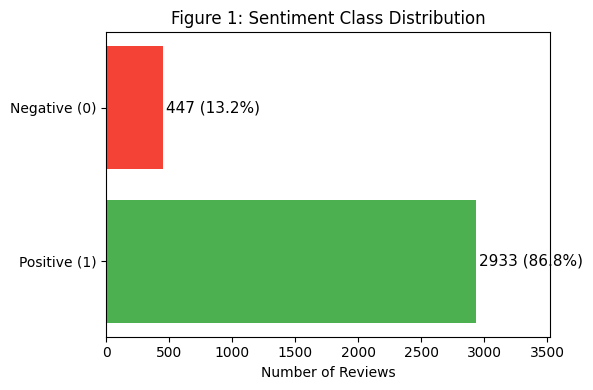

In [23]:
# --- Figure 1: Sentiment Class Distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
labels_plot = ['Positive (1)', 'Negative (0)']
counts = [pos, neg]
colors = ['#4CAF50', '#F44336']
bars = ax.barh(labels_plot, counts, color=colors)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{count} ({count/total*100:.1f}%)', va='center', fontsize=11)
ax.set_xlabel('Number of Reviews')
ax.set_title('Figure 1: Sentiment Class Distribution')
ax.set_xlim(0, max(counts) * 1.2)
plt.tight_layout()
plt.show()

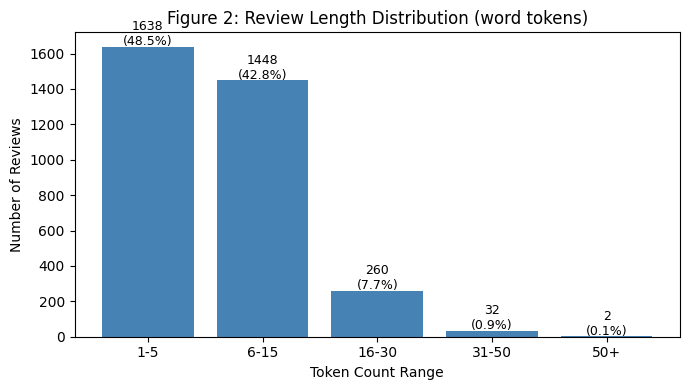

In [24]:
# --- Figure 2: Review Length Distribution ---
bins = [0, 5, 15, 30, 50, df['token_count'].max() + 1]
labels_bins = ['1-5', '6-15', '16-30', '31-50', '50+']
df['length_bin'] = pd.cut(df['token_count'], bins=bins, labels=labels_bins, right=True)
bin_counts = df['length_bin'].value_counts().reindex(labels_bins)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels_bins, bin_counts.values, color='steelblue')
for i, v in enumerate(bin_counts.values):
    ax.text(i, v + 10, f'{v}\n({v/total*100:.1f}%)', ha='center', fontsize=9)
ax.set_xlabel('Token Count Range')
ax.set_ylabel('Number of Reviews')
ax.set_title('Figure 2: Review Length Distribution (word tokens)')
plt.tight_layout()
plt.show()

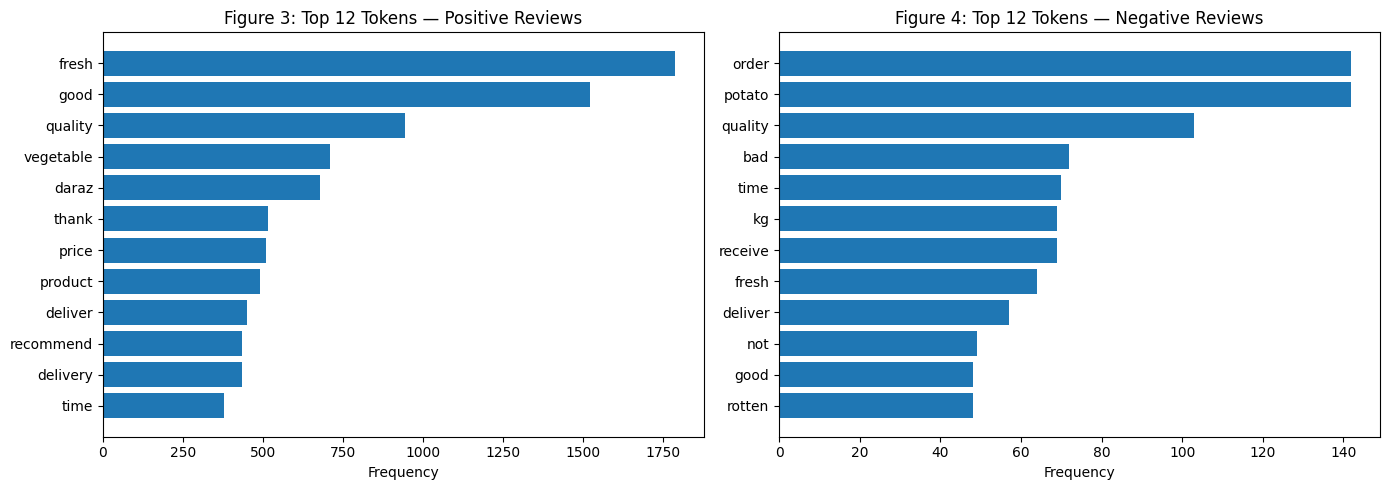

In [25]:
# --- Figures 3 & 4: Top 12 Token Frequencies by Sentiment ---
from collections import Counter

def top_tokens(subset, n=12):
    all_words = ' '.join(subset['Updated_reviews']).split()
    return Counter(all_words).most_common(n)

pos_df = df[df['Labels'] == 1]
neg_df = df[df['Labels'] == 0]
top_pos = top_tokens(pos_df)
top_neg = top_tokens(neg_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top, title in zip(axes, [top_pos, top_neg],
                          ['Figure 3: Top 12 Tokens — Positive Reviews',
                           'Figure 4: Top 12 Tokens — Negative Reviews']):
    words, freqs = zip(*top)
    ax.barh(words[::-1], freqs[::-1], color='#1f77b4')
    ax.set_xlabel('Frequency')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 5. Feature Extraction

In [26]:
# Bag-of-Words using CountVectorizer (no max_features cap — full vocab)
count_vec = CountVectorizer()
X = count_vec.fit_transform(df['Updated_reviews']).toarray()
y = df['Labels'].values
print(f'BoW feature matrix shape: {X.shape}')
print(f'Vocabulary size: {len(count_vec.vocabulary_)}')

BoW feature matrix shape: (3380, 2305)
Vocabulary size: 2305


## 6. Train/Test Split (Stratified 80/20)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0, stratify=y)
print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')
print(f'Test class distribution — Positive: {(y_test==1).sum()}, Negative: {(y_test==0).sum()}')

Training samples: 2704
Test samples: 676
Test class distribution — Positive: 587, Negative: 89


## 7. Model Building — Feedforward Neural Network

In [28]:
tf.random.set_seed(42)

nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

nn_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

nn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 100)            │       230,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,621 (904.77 KB)

 Trainable params: 231,621 (904.77 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
nn_history = nn_model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8580 - loss: 0.3822 - val_accuracy: 0.9231 - val_loss: 0.2199
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9508 - loss: 0.1456 - val_accuracy: 0.9453 - val_loss: 0.1633
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9671 - loss: 0.0911 - val_accuracy: 0.9408 - val_loss: 0.1660
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9786 - loss: 0.0656 - val_accuracy: 0.9408 - val_loss: 0.1753
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9834 - loss: 0.0513 - val_accuracy: 0.9453 - val_loss: 0.1872
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9871 - loss: 0.0417 - val_accuracy: 0.9438 - val_loss: 0.2007
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9893 - loss: 0.0353 - val_accuracy: 0.9423 - val_loss: 0.2143
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9904 - loss: 0.0308 - val_accuracy: 0.9453 - val_loss:

## 8. Model Evaluation

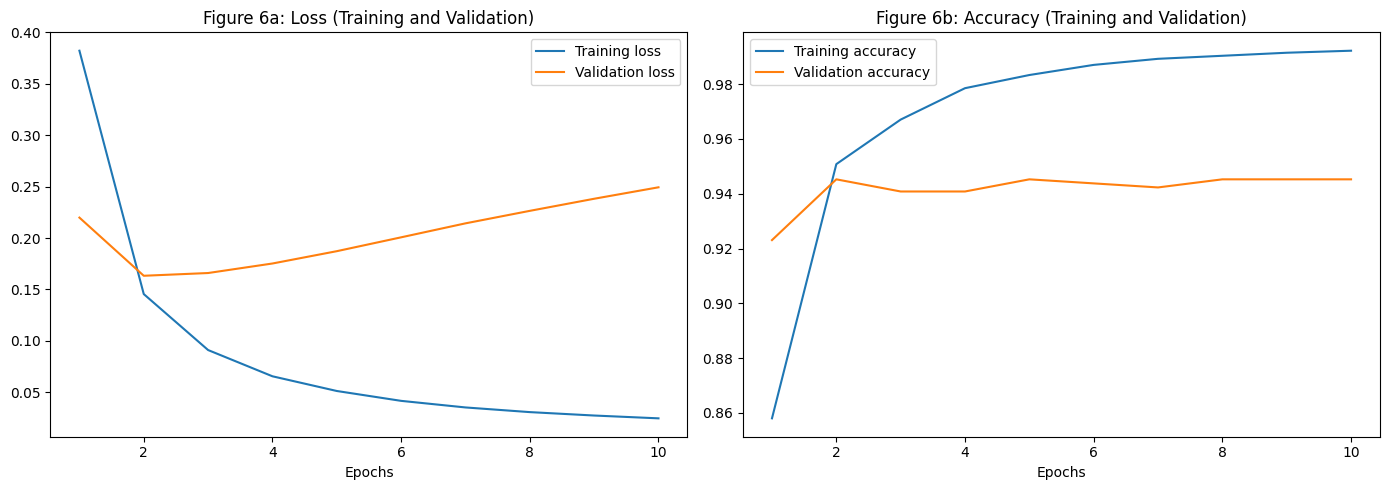

In [30]:
# --- Figure 6: Training & Validation Accuracy/Loss Curves ---
def plot_loss_curves(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, loss, label='Training loss')
    axes[0].plot(epochs, val_loss, label='Validation loss')
    axes[0].set_title('Figure 6a: Loss (Training and Validation)')
    axes[0].set_xlabel('Epochs')
    axes[0].legend()

    axes[1].plot(epochs, acc, label='Training accuracy')
    axes[1].plot(epochs, val_acc, label='Validation accuracy')
    axes[1].set_title('Figure 6b: Accuracy (Training and Validation)')
    axes[1].set_xlabel('Epochs')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_loss_curves(nn_history)

In [31]:
# --- Overall accuracy ---
loss, accuracy = nn_model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {accuracy*100:.2f}%')
print(f'Test Loss: {loss:.4f}')

Test Accuracy: 94.53%
Test Loss: 0.2494


In [32]:
# --- Predictions ---
y_preds_raw = nn_model.predict(X_test)
y_preds = tf.round(y_preds_raw).numpy().flatten().astype(int)

# --- Classification Report (Table 4) ---
print('=== Classification Report (Table 4) ===')
print(classification_report(y_test, y_preds,
      target_names=['Negative (0)', 'Positive (1)'],
      digits=3))

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Classification Report (Table 4) ===
              precision    recall  f1-score   support

Negative (0)      0.842     0.719     0.776        89
Positive (1)      0.958     0.980     0.969       587

    accuracy                          0.945       676
   macro avg      0.900     0.849     0.872       676
weighted avg      0.943     0.945     0.943       676



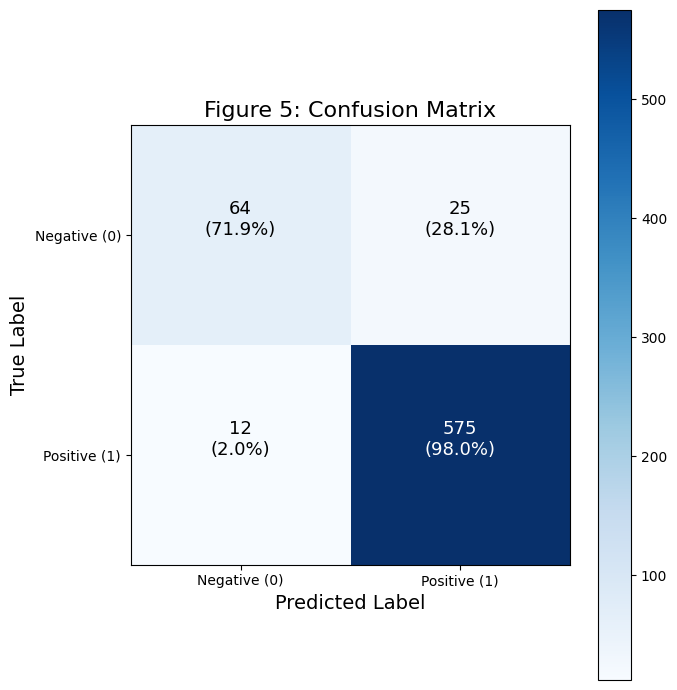

In [33]:
# --- Figure 5: Confusion Matrix ---
cm = confusion_matrix(y_test, y_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
n_classes = cm.shape[0]

fig, ax = plt.subplots(figsize=(7, 7))
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax)

class_labels = np.arange(n_classes)
ax.set(title='Figure 5: Confusion Matrix',
       xlabel='Predicted Label',
       ylabel='True Label',
       xticks=class_labels,
       yticks=class_labels,
       xticklabels=['Negative (0)', 'Positive (1)'],
       yticklabels=['Negative (0)', 'Positive (1)'])
ax.xaxis.set_label_position('bottom')
ax.xaxis.tick_bottom()
ax.yaxis.label.set_size(14)
ax.xaxis.label.set_size(14)
ax.title.set_size(16)

threshold = (cm.max() + cm.min()) / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i,
             f'{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)',
             horizontalalignment='center',
             color='white' if cm[i, j] > threshold else 'black',
             size=13)
plt.tight_layout()
plt.show()

## 9. Single-Sentence Prediction Demo

In [34]:
def predict_sentiment(sentence):
    # Apply same preprocessing pipeline
    text = sentence.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = remove_emoji(text)
    doc = nlp(text)
    cleaned = ' '.join([t.lemma_ for t in doc if not t.is_stop and t.is_alpha])
    # Use transform (NOT fit_transform) on existing vocabulary
    x = count_vec.transform([cleaned]).toarray()
    pred = tf.round(nn_model.predict(x)).numpy().flatten()[0]
    label = 'Positive' if int(pred) == 1 else 'Negative'
    print(f'Input: "{sentence}"')
    print(f'Cleaned: "{cleaned}"')
    print(f'Predicted sentiment: {label} ({int(pred)})')

predict_sentiment("I loved the product but don't buy it, it has problems.")
predict_sentiment("Great quality, fast delivery, highly recommend!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Input: "I loved the product but don't buy it, it has problems."
Cleaned: "love product not buy problem"
Predicted sentiment: Negative (0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Input: "Great quality, fast delivery, highly recommend!"
Cleaned: "great quality fast delivery highly recommend"
Predicted sentiment: Positive (1)
